# CLIPS Constructs

Refer the details in lecture notes 7.

# Section A: Conflict Resolution

* Set the **conflict resolution** strategies: 
 * **FCFS**: (set-strategy breadth) 
 * **Specificity**: (set-strategy lex) 
 * **Recency**: (set-strategy depth) 
 * **Highest Priority**: default (set-strategy lex), use salience

1. Refer to the Lab 4, question 3 - Create the conflict resolution based on **ordered fact**.

In [4]:
import clips
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# use either deffacts init or assert facts at below
# env.build("""(deffacts init
#                 (engine wont_start)
#                 (sound clicking_noise))""")

env.build("""(defrule R1
               (engine wont_start)
             =>
             (printout t "battery may be weak!" crlf))""")

env.build("""(defrule R2
               (engine wont_start)
               (sound silence)
             =>
             (printout t "starter is faulty!" crlf))""")

env.build("""(defrule R3
                (engine wont_start)
                (sound clicking_noise)
             =>
            (printout t "battery may be dead!" crlf))""")

# env.build("""(defrule R4
#                 (engine wont_start)
#                 (sound clicking_noise)
#              =>
#             (printout t "battery may be dead!" crlf))""")

env.reset()

# Debug
env.eval("(watch rules)") #(watch facts), ...

# Method 1: Set the conflict resolution strategy
#env.strategy = clips.Strategy.BREADTH  
#env.strategy = clips.Strategy.DEPTH    
#env.strategy = clips.Strategy.LEX      

# Method 2: Set the conflict resolution strategy
env.eval("(set-strategy breadth)")
#env.eval("(set-strategy depth)")
#env.eval("(set-strategy lex)")

# Scenario 1 (seperate facts, smae assertion statement)
# env.eval("(assert (engine wont_start)(sound clicking_noise))")

# Scenario 2
env.eval("(assert (sound clicking_noise))")
env.eval("(assert (engine wont_start))")

# showing the fired rules 
env.eval("(agenda)")

env.run()


0      R3: f-2,f-1
0      R1: f-2
For a total of 2 activations.
FIRE    1 R3: f-2,f-1
battery may be dead!
FIRE    2 R1: f-2
battery may be weak!


2

2. Based on highest priority based on user's salience

In [5]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# env.build("""(deffacts init
#                 (engine wont_start)
#                 (sound clicking_noise))""")

env.build("""(defrule R1
               (declare (salience 50))
               (engine wont_start)
             =>
             (printout t "battery may be weak!" crlf))""")

env.build("""(defrule R2
               (engine wont_start)
               (sound silence)
             =>
             (printout t "starter is faulty!" crlf))""")

env.build("""(defrule R3
                (declare (salience 30))
                (engine wont_start)
                (sound clicking_noise)
             =>
            (printout t "battery may be dead!" crlf))""")

env.reset()

# Debug
# env.eval("(watch rules)") #(watch facts), ...

env.eval("(set-strategy lex)")

# Scenario 1
env.eval("(assert (engine wont_start)(sound clicking_noise))")
# R1 then R3 because R1 have higher salience value

# Scenario 2
# env.eval("(assert (sound clicking_noise))")
# env.eval("(assert (engine wont_start))")
  
#env.eval("(agenda)")

env.run()


battery may be weak!
battery may be dead!


2

3. Refer to the same question - Create the conflict resolution based on **unordered fact**.

In [8]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate car
               (slot engine)
               (slot sound))""")

env.build("""(defrule R1
               (car (engine wont_start))
             =>
             (printout t "battery may be weak!" crlf))""")

env.build("""(defrule R2
               (car (engine wont_start)
                    (sound silence))
             =>
             (printout t "starter is faulty!" crlf))""")

env.build("""(defrule R3
               (car (engine wont_start)
                    (sound clicking_noise))
             =>
            (printout t "battery may be dead!" crlf))""")

env.reset()

# Debug
env.eval("(watch rules)") #(watch facts), ...

env.eval("(set-strategy breadth)")
#env.eval("(set-strategy depth)")
#env.eval("(set-strategy lex)")

# Scenario 3
# env.eval("(assert (car (engine wont_start)(sound clicking_noise)))")
# breadth: R1 and 3
# R3 then 1
# depth: 3 then 1
# lex: 3 then 1

# Scenario 4
env.eval("(assert (car (sound clicking_noise)))")
env.eval("(assert (car (engine wont_start)))")
  
#env.eval("(agenda)")

env.run()

FIRE    1 R1: f-2
battery may be weak!


1

# Section B: Backward Chaining 

In **CLIPS**, **default inference** is using **forward chaining** technique. Example **backward chaining** technique below is just a basic implementation. For complete backward chaining, the implementation must consider for the **conflict resolution** as well.

In [9]:
import clips

# Initialize CLIPS environment
env = clips.Environment()

# Initialize facts
env.build("""(deffacts init (ingredient flour)
                          (ingredient eggs)
                          (ingredient sugar)
                          (have-time yes))""")

# Define CLIPS rules and facts
env.build("""(defrule rule1
               (ingredient flour)
               (ingredient eggs)
               (ingredient sugar)
             => (assert (action bake-cake)))""")

env.build("""(defrule rule2
                (or (not (ingredient flour))
                (not (ingredient eggs))
                (not (ingredient sugar)))
             => (assert (action buy-cake)))""")

env.build("""(defrule rule3
                (have-time yes)
             => (assert (result bake-cake)))""")


env.reset()

#Backward chaining function
def backward_chain(goal):
    
    # step 1
    # Check the goal before running inference
    # loops through current available facts
    for fact in env.facts():
        if str(fact) == goal:   # convert each fatcs to string for comparison
            return True

    # step 2
    # Before inference
    # count number of facts currently in KB
    initial_facts = len(list(env.facts())) #return 4
    
    # After inference
    # count number of facts after running the working memory
    env.run()  
    final_facts = len(list(env.facts())) # return 6

    # step 3
    # Check the goal after running inference
    for fact in env.facts():
        if str(fact) == goal:
            return True

    # step 4
    # stop recursion if no new facts
    if initial_facts == final_facts:
        return False

    # step 5
    # ask the function rerun itself with same goal, but with updated KB
    # Recursive function
    return backward_chain(goal)

# Goal to achieve
goal = "(result bake-cake)"

# Perform backward chaining
if backward_chain(goal):
    print(f"Goal achieved: {goal}")
else:
    print(f"Goal could not be achieved: {goal}")

#Print final facts
print("\nFinal Facts in the Knowledge Base:")
for fact in env.facts():
    print(fact)


Goal achieved: (result bake-cake)

Final Facts in the Knowledge Base:
(ingredient flour)
(ingredient eggs)
(ingredient sugar)
(have-time yes)
(result bake-cake)
(action bake-cake)


# Section C: Semantic-based Expert System

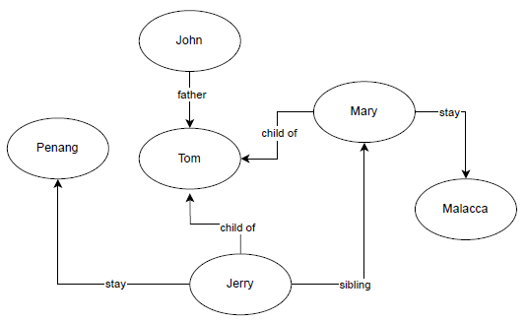

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

#                             john is father of tom
env.build("""(deffacts family (father John Tom)
                              (child Mary Tom)
                              (child Jerry Tom)
                              (stay Mary Malacca)
                              (sibling Jerry Mary)
                              (stay Jerry Penang))""")

env.build("""(defrule who-is-the-sibling-of-Jerry
                    (sibling Jerry ?sis)
                     => (printout t "Jerry's sibling is " ?sis crlf))""")


env.build("""(defrule where-does-Jerry-stay 
                    (stay Jerry ?place)
                     =>(printout t "Jerry stays at " ?place crlf))""")

env.reset()

env.run()


# Section D: Knowledge-Based Expert System

* Diagram below is a **frame-based knowledge representation**. Create **CLIPS contructs** for **classes** and build **inheritance (is-a)** and **instance** relationships. As well as **has-a (aggregation)** and **has-a (composition)** relationships. The **reasoning** here is to locate the instance of garfield and snoopy. The **challenges of user interface** are **users' inputs are varies**, choose the facts from words and **match** with predefined facts in a Expert System is important. Additional to this, **auto word correction** and **lower case the words** could make further accurate results. Therefore, this example is enhanced with **natural language processing (NLP)** to overcome the challenges. Furthermore, the **text-to-speech** could make the Expert System more **interactive experience**.

In [ ]:
#pip install pyttsx3

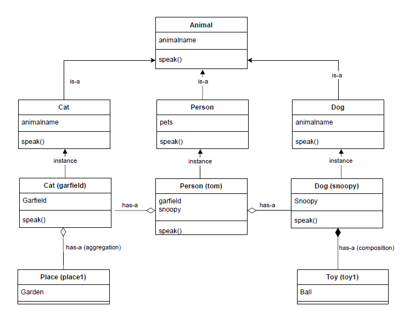

1. Create frames with **is-a** relationship

In [10]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# Animal = class name
# is-a USER = parent class/root class
#           = does not inherit any properties from other custom class
env.build("""(defclass Animal (is-a USER)
                (slot animalname))""")

# Dog = class name
# is-a Animal = chill class/subclass
#             = inherit all properties of Animal class
env.build("""(defclass Dog (is-a Animal)
               (slot animalname)
               (slot has-toy))""")

env.build("""(defclass Cat (is-a Animal)
               (slot animalname)
               (slot place))""")

env.build("""(defclass Toy (is-a USER)
               (slot toyname))""")

env.build("""(defclass Place (is-a USER)
               (slot placename))""")

env.build("""(defclass Person (is-a USER)
               (multislot pets))""")
   

2. Attach **function(s)** to a class

In [11]:
# efmessage-handler = define specific actions that object of class performed
#                   = speak : handler
env.build("""(defmessage-handler Animal speak ()
               (printout t "Animal make sound ..." crlf))""")

env.build("""(defmessage-handler Dog speak ()
               (assert (animal "Bark bark ...")))""")

env.build("""(defmessage-handler Cat speak ()
               (assert (animal "Meow meow ...")))""")

2. Create an **instance** with **has-a (composition)** relationship

In [13]:
# syntax : (make-instance <instance-name> of <class-name> (<slot-name> <value>))
# make-instance = use to create object from class
# instance-name = snoopy
# slot-name = snoopy
# value = (has-toy (make-instance toy1 of toy (toyname Ball)))
env.eval("""(make-instance snoopy of Dog (animalname Snoopy)
                                       (has-toy (make-instance toy1 of Toy (toyname Ball))))""")

'snoopy'

3. Create an **instance** with **has-a(aggregation)** relationship

In [14]:
env.eval("""(make-instance place1 of Place (placename Garden))""")

env.eval("""(make-instance garfield of Cat (animalname Garfield)
                                       (place place1))""")

'garfield'

4. Create an **instance** with **has-a(aggregation)** relationship with **more than one instances**

In [15]:
# $create = accept more than one instance
env.eval("""(make-instance tom of Person (pets (create$ snoopy garfield)))""")

'tom'

5. Adjust your speaker accordingly to experience the **text to speech**.

In [18]:
import pyttsx3

engine = pyttsx3.init()

# speak up to 200 words per minite
engine.setProperty('rate',200)

# Example input = garfield
# Example input = snoopy
user_input=input("Enter your favourite animal to speak with you.")

#env.eval("(find-all-instances ((?ins USER)) TRUE)")

try:
    # find instance of USER that matches user_input
    # <find-instance> = search for specific instance
    # <?ins USER> = search instance in USER
    # <eq [] ?ins> = check whether instance name equal to user_input
    env.eval("(bind ?output (find-instance ((?ins USER)) (eq [" + user_input + "] ?ins)))")
    
    # remove all previous assert facts in animal
    env.eval("""(do-for-all-facts ((?f animal)) (retract ?f))""")

    # get <speak> to the instance found in ?output
    # nth$ <index><list> = retrive elements
    # <index> = position, <list> = list from which element to retrieved
    env.eval("""(send (nth$ 1 ?output) speak)""")
    
    # speak the first fact in KB
    engine.say(list(env.facts())[0][0])
    engine.runAndWait()
    
except Exception as e:
    engine.say("Sorry, cannot find!")
    engine.runAndWait()


6. Enhance user interface through **Natural Language Processing (NLP)**

In [ ]:
#pip install pyspellchecker
#nltk.download('punkt_tab')
#nltk.download('punkt')
#nltk.download('wordnet')
#nltk.download('stopwords')
#nltk.download('averaged_perceptron_tagger')
#nltk.download('averaged_perceptron_tagger_eng')
#nltk.download('omw-1.4')

In [19]:
import nltk

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\U

True

In [21]:
import nltk
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from spellchecker import SpellChecker
from clips import Environment

# Function to enhance input
def corrected_input(user_input):
    
    spell = SpellChecker()
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words("english"))

    # Tokenize input
    tokens = word_tokenize(user_input)
    
    # POS tagging
    tagged_words =pos_tag(tokens)

    corrected_words = []
    for word,tag in tagged_words:
         # Skip stop words
        if word.lower() not in stop_words:
            # Filtered words for (proper noun, singular), (common noun, singular, plural)
            if tag in ['NNP','NN','NNS']: 
                if tag in ['NN','NNS']: # Only correct (common noun, singular, plural) in the dictionary
                    corrected = spell.correction(word) if word.lower() not in spell and word.isalpha() else word
                else: # Garfield & Snoopy
                    corrected = word
                
                # Lemmatize the corrected word
                lemma = lemmatizer.lemmatize(corrected)
                corrected_words.append(lemma)

    return " ".join(corrected_words)


In [28]:
import pyttsx3

engine = pyttsx3.init()

engine.setProperty('rate',200)

# Example input = I love Garfield
# Example input = I love Snoopy
user_input=input("Enter your favourite animal to speak with you.")
filtered_user_input = corrected_input(user_input).lower()
print(filtered_user_input)

try:
    env.eval("(bind ?output (find-instance ((?ins USER)) (eq [" + filtered_user_input + "] ?ins)))")
    env.eval("""(do-for-all-facts ((?f animal)) (retract ?f))""")
    env.eval("(send (nth$ 1 ?output) speak)")
    engine.say(list(env.facts())[0][0])
    engine.runAndWait()
    
except Exception as e:
    engine.say("Sorry, cannot find! Please provide additional context.")
    engine.runAndWait()   


[MSGFUN1] No applicable primary message-handlers found for 'speak'.


harm garfield


# Section D: Car Troubleshooting Expert System Through Case-based Reasoning

4R - **R**epresenting, **R**etrieve, **R**euse and **R**etain

1. Create the facts below to the case_library.txt and save into the same folder with the Lab 7.ipynb <br>
(car-troubleshooting (can-start yes) (engine-noise 200) (solution replace-belt)) <br>
(car-troubleshooting (can-start yes) (engine-noise 80) (solution check-battery)) <br>
(car-troubleshooting (can-start no) (engine-noise 0) (solution check-fuel))

In [29]:
import clips 
import logging
from datetime import datetime

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# designed for troubleshooting car issues based on similarity between query and pre-existing case

# Representing a case
env.build("""(deftemplate car-troubleshooting
                   (slot can-start)
                   (slot engine-noise)
                   (slot solution))""")

env.build("""(deftemplate car-query
                   (slot can-start)
                   (slot engine-noise))""")

env.build("""(deftemplate similarity
                   (slot solution)
                   (slot score))""")


# Load case library
# env.build("""(deffacts case (car-troubleshooting (can-start yes) (engine-noise 200) (solution replace-belt))
#                             (car-troubleshooting (can-start yes) (engine-noise 80) (solution check-battery))
#                             (car-troubleshooting (can-start no) (engine-noise 0) (solution check-fuel)))""")

fact=""
with open('case_library.txt', 'r') as file:
    for line in file:
        fact=fact+line.strip()
    env.build("""(deffacts case """+fact+""")""")
        
# Retrieve similar case
# ?query = capture facts of car-query
# ?case = captures fact of car-troubleshooting
env.build("""(defrule calculate-similarity
                 ?query <- (car-query (can-start ?query-start) (engine-noise ?query-noise))
                 ?case <- (car-troubleshooting (can-start ?case-start) (engine-noise ?case-noise) (solution ?case-solution))
              =>  (bind ?score 0) ;initialize the ?score as 0
                  (if (eq ?query-start ?case-start) then (bind ?score (+ ?score 1)))                ;;+1 if can-start is match
                  (bind ?noise-diff (abs (- ?query-noise ?case-noise)))                             ;;similarity of engine-noise
                  (if (<= ?noise-diff 50) then (bind ?score (+ ?score (- 1 (/ ?noise-diff 50.0))))) ;;tolerance +/-50
                  (assert (similarity (solution ?case-solution) (score ?score))))""") # assert new facts

# print out all similarity scores and their associated solutions
env.build("""(defrule retrieve-most-similar
                  (similarity (solution ?case-solution) (score ?score))
             =>(printout t "Most similar case: " ?case-solution " with similarity score: " ?score crlf))""")

# solution of heighest similarity score
# highest similarity score
# nil = no solution defined yet
# -1 = placeholder until valid score found
env.build("(defglobal ?*max-solution* = nil)")
env.build("(defglobal ?*max-score* = -1)")

# check similarity facts and updates the global variables if higher score found
env.build("""(defrule find-max-score
               (similarity (solution ?solution) (score ?score))
               (test (> ?score ?*max-score*))
              =>(bind ?*max-score* ?score)
                (bind ?*max-solution* ?solution))""")

env.eval("(ppdeffacts case)")

(deffacts MAIN::case
   (car-troubleshooting (can-start yes) (engine-noise 200) (solution replace-belt))
   (car-troubleshooting (can-start yes) (engine-noise 80) (solution check-battery))
   (car-troubleshooting (can-start no) (engine-noise 0) (solution check-fuel)))


2. Reuse and retain the solution. Check the new solution has been added to the case_library.txt.

In [30]:
env.reset()
query="(car-query (can-start yes) (engine-noise 100))" # remove hash tag for reuse solution
env.eval("(assert " +query+")")
env.run()

# Reuse the solution
env.build("""(defrule reuse-solution-retain
                    (test (> 1.8 ?*max-score*))
              => (printout t "Suggested solution:" ?*max-solution* " with similarity score:" ?*max-score* crlf))""")

env.run()

# Retain
#print("(car-troubleshooting ("+query[12:-1]+"(solution "+env.eval("?*max-solution*")+"))")
with open('case_library.txt', 'a') as file:
    file.writelines("(car-troubleshooting ("+query[12:-1]+"(solution "+env.eval("?*max-solution*")+"))\n")
    

Most similar case: check-fuel with similarity score: 0
Most similar case: check-battery with similarity score: 1.6
Most similar case: replace-belt with similarity score: 1
Suggested solution:check-battery with similarity score:1.6


3. Revise and retain as no solution. Check the facts without solution has been added to the case_library.txt.

In [31]:
env.eval("(undefrule reuse-solution-retain)")

env.reset()
query="(car-query (can-start no) (engine-noise 150))"   # remove hash tag for revise solution

env.eval("(assert " +query+")")
env.run()

# Revise the solution
env.build("""(defrule revise-solution-retain
                    (test (< 0.5 ?*max-score*))
              => (bind ?*max-solution* None)
                 (printout t "No solution!" crlf))""")

env.run()

# Retain
#print("(car-troubleshooting ("+query[12:-1]+"(solution "+env.eval("?*max-solution*")+"))")
with open('case_library.txt', 'a') as file:
    file.writelines("(car-troubleshooting ("+query[12:-1]+"(solution "+env.eval("?*max-solution*")+"))\n")
    

Most similar case: check-fuel with similarity score: 1
Most similar case: check-battery with similarity score: 0
Most similar case: replace-belt with similarity score: 0.0
No solution!


* Manual Handling Unsolved Cases

In [32]:
import clips 
import logging
from datetime import datetime

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# Representing a case
env.build("""(deftemplate car-troubleshooting
                   (slot can-start)
                   (slot engine-noise)
                   (slot solution))""")

env.build("""(deftemplate car-query
                   (slot can-start)
                   (slot engine-noise))""")

env.build("""(deftemplate similarity
                   (slot solution)
                   (slot score))""")


fact=""
with open('case_library.txt', 'r') as file:
    for line in file:
        fact=fact+line.strip()
    env.build("""(deffacts case """+fact+""")""")
        
# Retrieve all cases without solutions 
env.build("""(defrule store-new-unsolved-case
                    (car-troubleshooting (can-start ?p1)
                                         (engine-noise ?p2)
                                         (solution None))
             => (printout t "New unsolved case stored: can-start " ?p1 "; engine-noise " ?p2 crlf))""")

env.reset()

env.run()

# Domain expert manually update to the knowledge based
# Open the case library and replace the text


New unsolved case stored: can-start no; engine-noise 150


1

# Section E:  Hybrid with Machine Learning (Decision Tree) for Adaptability

* In traditional method, domain expert manually updates into the KB. A simple example of **modern approach** how expert systems hybrid with **machine learning** techniques for **adaptability**.

|--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



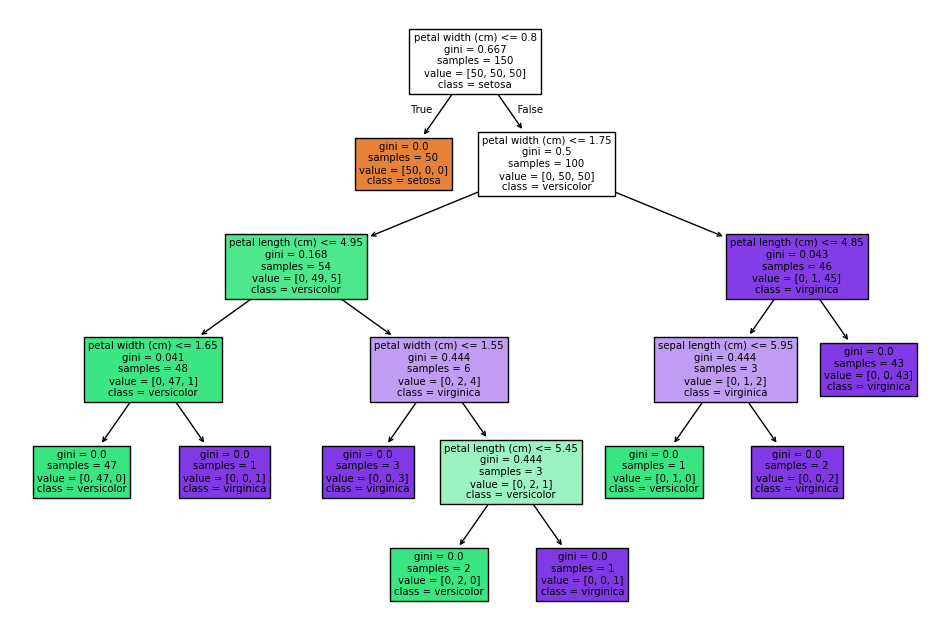

In [34]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# decision tree (DT)
# floatchart like structure use to make decision and prediction
# nodes where represent decision

# Load dataset
data = load_iris()
# iris dataset = contain 150 smples from 3 species of flower
X = data.data   # features of your data
y = data.target # class

# Train the dataset
clf = DecisionTreeClassifier(max_depth=5)
clf.fit(X, y)

# Convert the rules to text
rules = export_text(clf, feature_names=data.feature_names)
print(rules)

# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=data.feature_names, class_names=data.target_names, filled=True)
# If doesn't work, please use below.
#plot_tree(clf)
plt.show()


## Excercise:

1. Simulate the DFS/BFS based on 8 puzzle games https://github.com/memoodm/AI-8Puzzle-SearchAlgorithm <br>
2. Simulate the FuzzyCLIPS (https://sourceforge.net/projects/clipsrules/files/)
